# Deep Learning — Projeto Final

> Previsão de cancelamento de reservas hoteleiras com redes neuronais

**Curso:** Pós-graduação em Data Science e Business Intelligence  
**Disciplina:** Deep Learning  
**Aluno:** Ricardo Filipe Fernandes da Silva

---

## Índice

1. [Imports e Setup](#1-imports-e-setup)
2. [Load Data](#2-load-data)
3. [Análise Exploratória (EDA)](#3-análise-exploratória-eda)
4. [Preparação dos Dados](#4-preparação-dos-dados)
5. [Definição do Problema](#5-definição-do-problema)
6. [Modelação — FNN (Baseline e Progressão)](#6-modelação--fnn-baseline-e-progressão)
7. [Modelação — CNN (Abordagem Convolucional)](#7-modelação--cnn-abordagem-convolucional)
8. [Comparação de Modelos](#8-comparação-de-modelos)
9. [Utilidade do Modelo](#9-utilidade-do-modelo)
10. [Conclusões, Limitações e Trabalho Futuro](#10-conclusões-limitações-e-trabalho-futuro)


# 1. Imports e Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1.1 Funções Auxiliares

Funções reutilizáveis para EDA, treino, avaliação e comparação de modelos. Centralizadas nesta secção para evitar repetição ao longo do notebook.

In [2]:
# ── EDA ──────────────────────────────────────────────────────────────────────

def dataset_overview(df):
    print(f"Shape: {df.shape}")
    print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\nDuplicates: {df.duplicated().sum()}")
    print(f"\nTarget distribution:\n{df['is_canceled'].value_counts(normalize=True).round(3)}")

def plot_missing(df):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print("No missing values.")
        return
    (missing / len(df) * 100).plot(kind='bar', figsize=(8, 4), color='steelblue')
    plt.ylabel('% missing')
    plt.title('Percentage of Missing Values by Column')
    plt.tight_layout()
    plt.show()

def plot_target(df):
    counts = df["is_canceled"].value_counts().sort_index()
    proportions = (df["is_canceled"].value_counts(normalize=True).sort_index() * 100).round(2)
    print("Target distribution (count):\n", counts)
    print("\nTarget distribution (%):\n", proportions)
    counts.plot(kind="bar", figsize=(6, 4))
    plt.title("Distribution of is_canceled")
    plt.xlabel("is_canceled")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

def plot_numeric(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df[col].dropna(), bins=40, edgecolor="black")
    axes[0].set_title(f"Distribution: {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    df.boxplot(column=col, by="is_canceled", ax=axes[1])
    axes[1].set_title(f"{col} by cancellation")
    axes[1].set_xlabel("is_canceled")
    axes[1].set_ylabel(col)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

def plot_categorical(df, col, top_n=10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    df[col].value_counts().head(top_n).plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Frequency: {col}')
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False).head(top_n)
    cancel_rate.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title(f'Cancellation Rate by {col}')
    axes[1].axhline(df['is_canceled'].mean(), color='red', linestyle='--', label='overall avg')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_target_correlation(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    corr = (df[num_cols].corr()['is_canceled']
            .drop('is_canceled')
            .sort_values(key=abs, ascending=True))
    colors = ['coral' if x < 0 else 'steelblue' for x in corr]
    fig, ax = plt.subplots(figsize=(8, 7))
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Correlação das features com is_canceled')
    ax.set_xlabel('Pearson correlation')
    plt.tight_layout()
    plt.show()
    return corr.sort_values(key=abs, ascending=False)

# ── MODELO ───────────────────────────────────────────────────────────────────

def compile_model(model):
    """Compilação padrão para classificação binária."""
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

def train_model(model, X_train, y_train, X_val, y_val,
                epochs=20, batch_size=32, patience=5):
    """Treina o modelo com EarlyStopping. Devolve o histórico."""
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    return history

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    """Avalia o modelo nos três conjuntos. Devolve dicionário com métricas."""
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss,   val_acc   = model.evaluate(X_val,   y_val,   verbose=0)
    test_loss,  test_acc  = model.evaluate(X_test,  y_test,  verbose=0)
    print(f"  Train Accuracy      : {train_acc:.4f}")
    print(f"  Validation Accuracy : {val_acc:.4f}")
    print(f"  Test Accuracy       : {test_acc:.4f}")
    return {
        "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc,
        "train_loss": train_loss, "val_loss": val_loss, "test_loss": test_loss
    }

def plot_history(history, title="Model"):
    """Plota curvas de accuracy e loss (treino vs validação)."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(history.history[metric], label="Train")
        ax.plot(history.history[f"val_{metric}"], label="Validation")
        ax.set_title(f"{title} — {metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend()
    plt.tight_layout()
    plt.show()

def compare_models(results: dict) -> pd.DataFrame:
    """Recebe um dict {nome_modelo: {train_acc, val_acc, test_acc}} e devolve tabela."""
    df = pd.DataFrame(results).T[["train_acc", "val_acc", "test_acc"]]
    df.columns = ["Train Acc", "Val Acc", "Test Acc"]
    return df.applymap(lambda x: f"{x:.4f}")

def reshape_for_cnn(X):
    """Reformula array 2D para formato Conv1D: (n, features, 1)."""
    return X.reshape(X.shape[0], X.shape[1], 1)


# 2. Load Data

In [3]:
# Ajustar o caminho se necessário
DATA_PATH = r"C:\Projetos\hotel_cancellation_deeplearning\data\hotel_bookings.csv"

df = pd.read_csv(DATA_PATH)
display(df.head())


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2.1 Visão Geral do Dataset

In [4]:
dataset_overview(df)

Shape: (119390, 32)

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64

Duplicates: 31994

Target distribution:
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


# 3. Análise Exploratória (EDA)

## 3.1 Missing Values

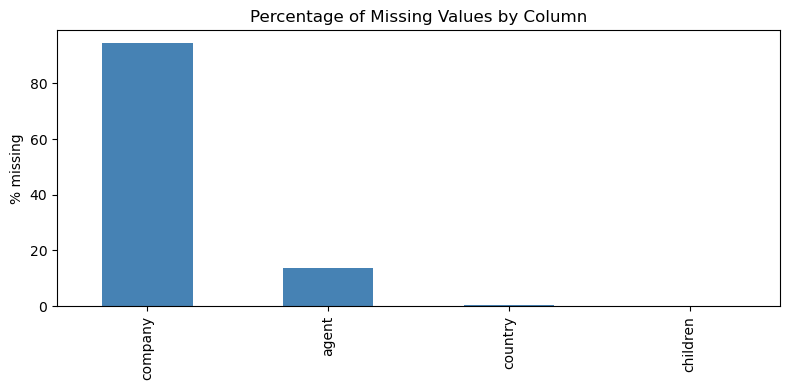

In [5]:
plot_missing(df)

## 3.2 Variável Target

Target distribution (count):
 is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target distribution (%):
 is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


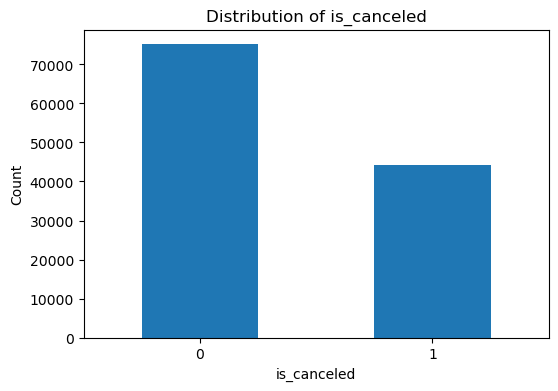

In [6]:
plot_target(df)

## 3.3 Variáveis Numéricas Relevantes

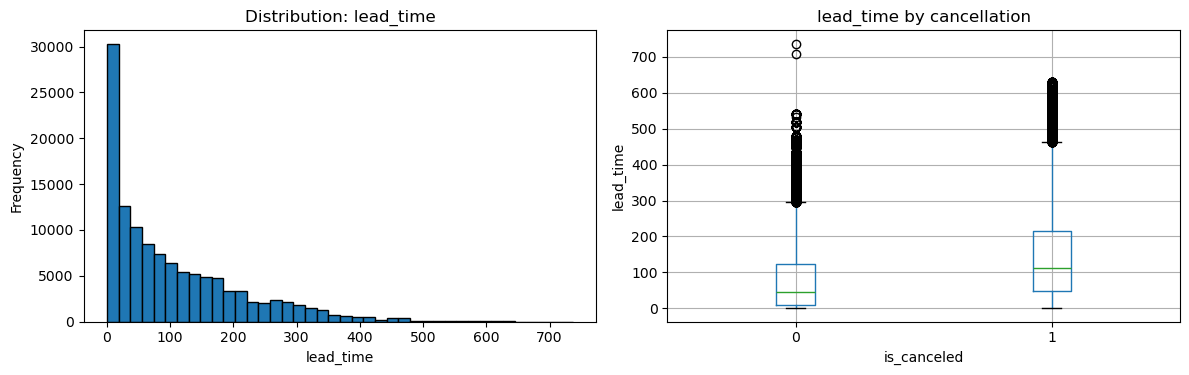

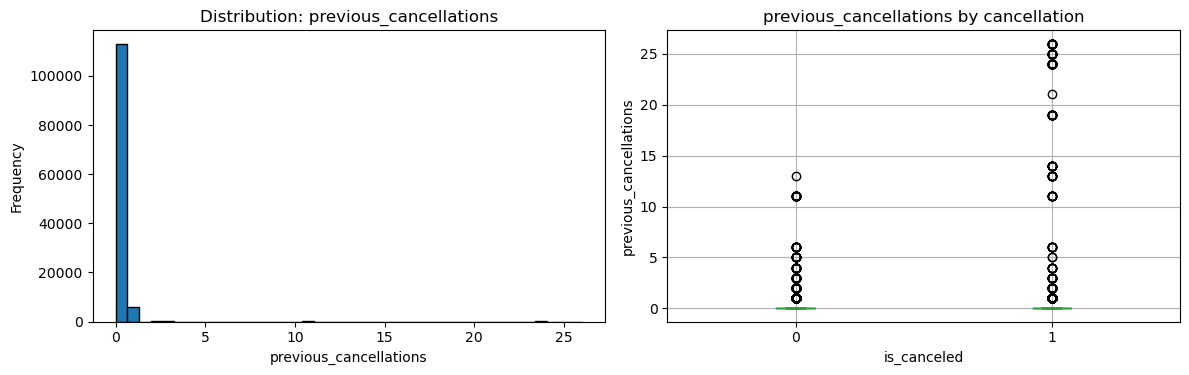

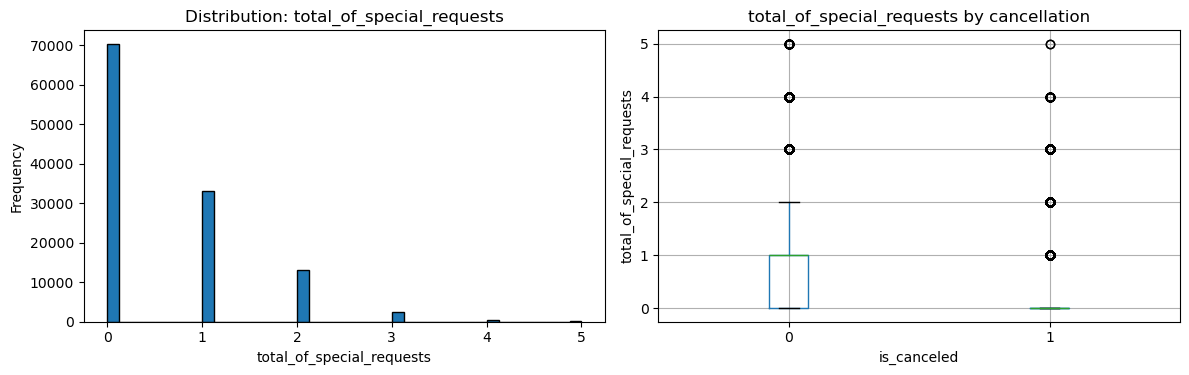

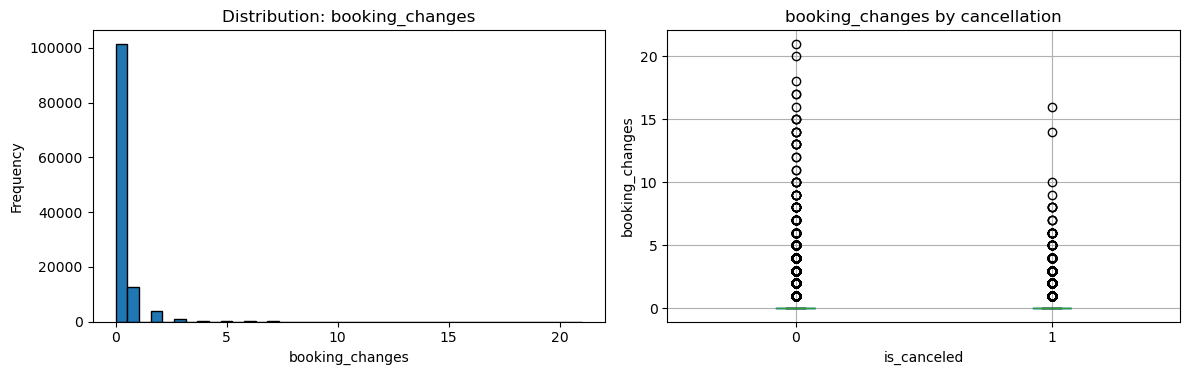

In [7]:
numeric_vars = [
    "lead_time",
    "previous_cancellations",
    "total_of_special_requests",
    "booking_changes"
]

for col in numeric_vars:
    plot_numeric(df, col)


## 3.4 Variáveis Categóricas Relevantes

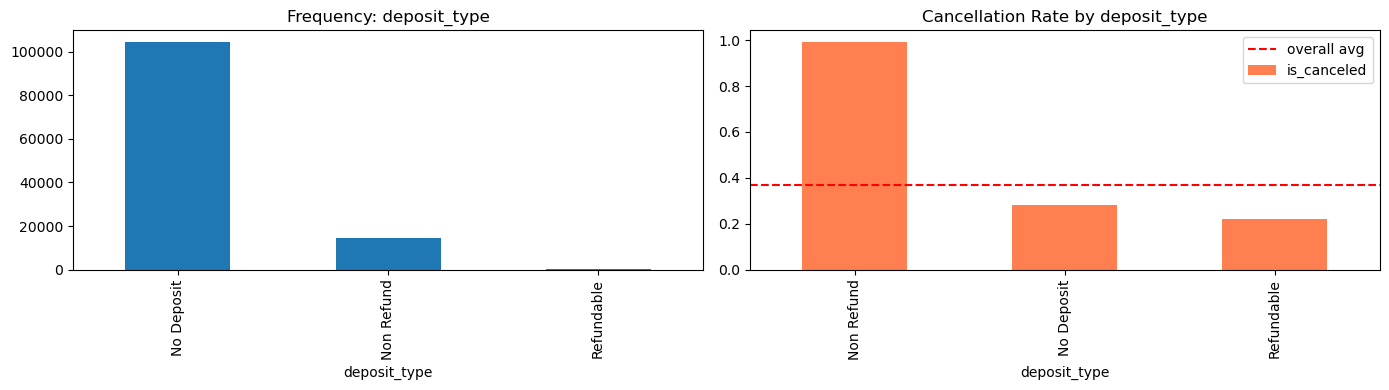

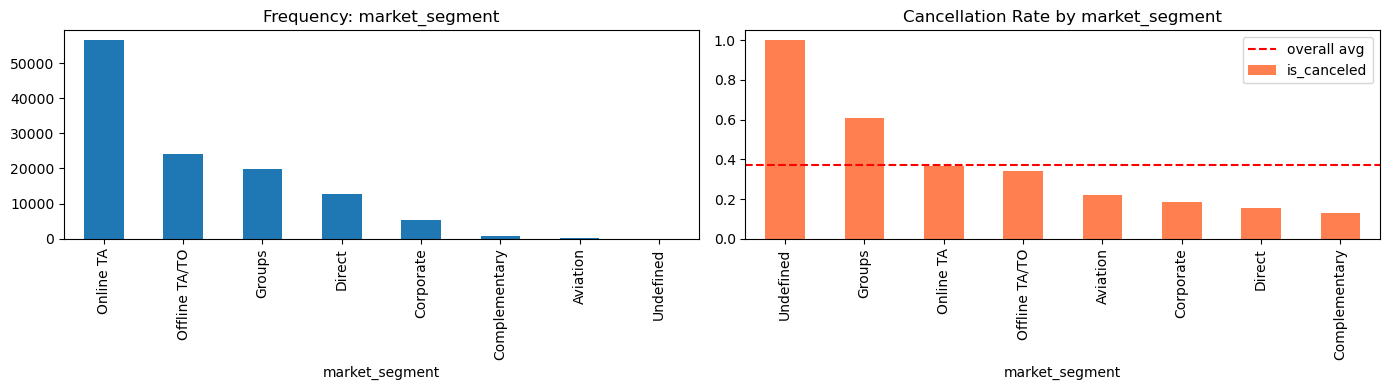

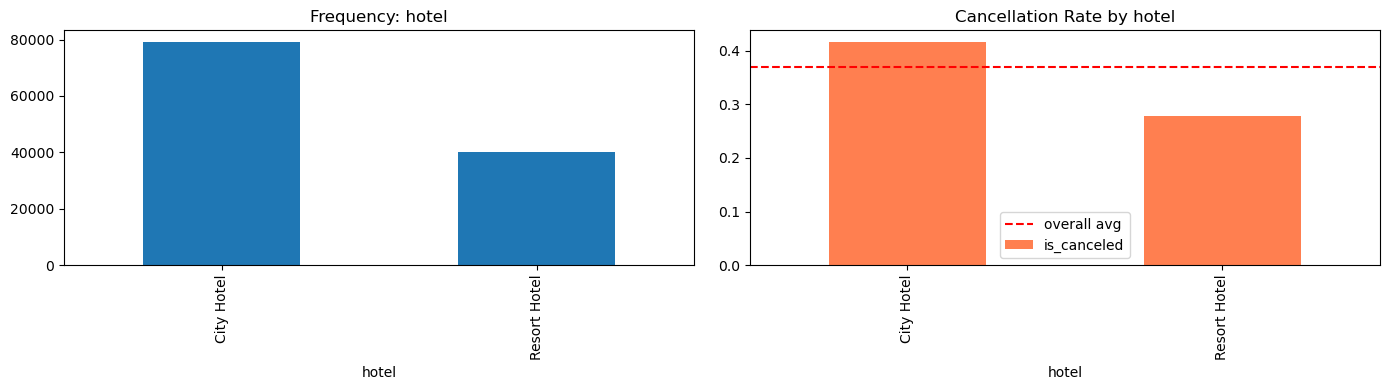

In [8]:
categorical_vars = [
    "deposit_type",
    "market_segment",
    "hotel"
]

for col in categorical_vars:
    plot_categorical(df, col)


## 3.5 Correlação com a Target

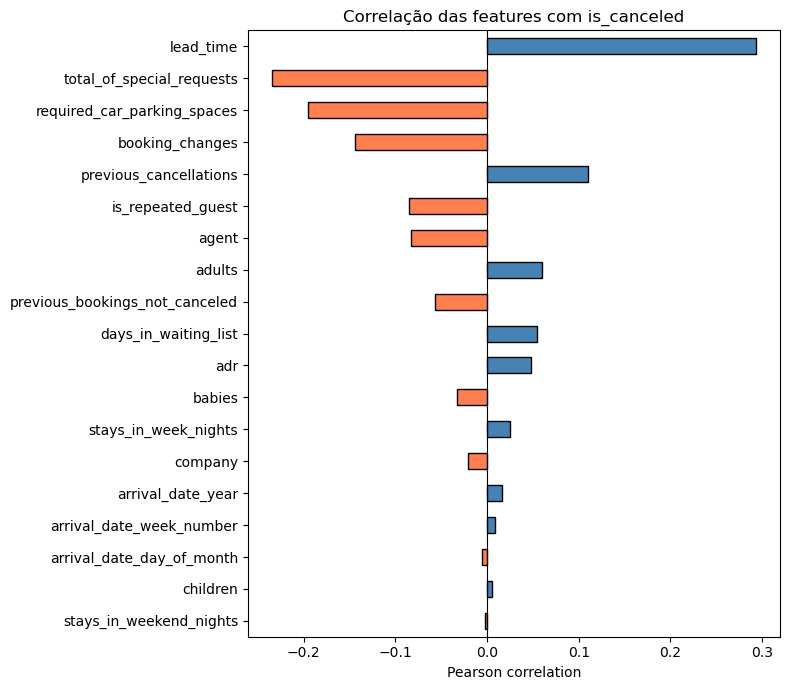

lead_time                         0.293123
total_of_special_requests        -0.234658
required_car_parking_spaces      -0.195498
booking_changes                  -0.144381
previous_cancellations            0.110133
is_repeated_guest                -0.084793
agent                            -0.083114
adults                            0.060017
previous_bookings_not_canceled   -0.057358
days_in_waiting_list              0.054186
Name: is_canceled, dtype: float64


In [9]:
corr = plot_target_correlation(df)
print(corr.head(10))


## 3.6 Principais Insights da EDA

O dataset apresenta 119.390 observações e 32 variáveis, incluindo informação numérica e categórica sobre a reserva, o cliente, o canal comercial e aspetos operacionais da estadia. Foram identificados missing values, sobretudo em `agent` e `company`, bem como 31.994 observações duplicadas, que serão analisadas na fase de preparação dos dados.

A variável target `is_canceled` apresenta uma distribuição de cerca de 63% de reservas não canceladas e 37% de reservas canceladas, não evidenciando um desequilíbrio extremo. A sua variação ao longo do tempo reforça a utilização de uma divisão cronológica dos dados.

Entre as variáveis numéricas analisadas, `lead_time` destaca-se como a mais relevante, mostrando diferenças claras entre reservas canceladas e não canceladas. Entre as variáveis categóricas, `deposit_type`, `market_segment` e `hotel` revelam maior capacidade explicativa para o problema em estudo.

A variável `deposit_type` mostra forte capacidade discriminativa, com a categoria `Non Refund` a apresentar uma taxa de cancelamento bastante superior à média global. Em `market_segment`, verificam-se diferenças relevantes entre segmentos, com destaque para categorias como `Groups`, que aparentam maior risco de cancelamento.


# 4. Preparação dos Dados

## 4.1 Registos Duplicados

O dataset contém registos com valores idênticos em todas as colunas. A ausência de um identificador único de cliente ou de reserva impede confirmar se estes registos são efetivamente duplicados ou, pelo contrário, observações legítimas distintas. Acresce que a remoção dos duplicados alteraria significativamente as proporções da variável target (de ~37% para ~27,5% de cancelamentos).

Por estas razões, optou-se por **não remover os duplicados** nesta fase, ficando essa decisão dependente de análise adicional.


In [10]:
# Análise dos duplicados
n_dup = df.duplicated().sum()
print(f"Duplicados exatos: {n_dup} ({n_dup/len(df)*100:.1f}%)")
print("\nDistribuição original:")
print(df["is_canceled"].value_counts(normalize=True).round(4))
print("\nDistribuição sem duplicados:")
print(df.drop_duplicates()["is_canceled"].value_counts(normalize=True).round(4))


Duplicados exatos: 31994 (26.8%)

Distribuição original:
is_canceled
0    0.6296
1    0.3704
Name: proportion, dtype: float64

Distribuição sem duplicados:
is_canceled
0    0.7251
1    0.2749
Name: proportion, dtype: float64


## 4.2 Limpeza e Missing Values

A coluna `company` apresenta 94,31% de valores em falta e será removida. A coluna `children` tem apenas 4 valores em falta — serão imputados com 0. As colunas `country` e `agent` terão categorias explícitas de ausência ("Unknown" / "No_Agent"), preservando a informação de que o valor estava ausente.


In [11]:
df_clean = df.copy()

# Remover coluna com missing excessivo
df_clean = df_clean.drop(columns=["company"])

# Tratar missing values
df_clean["children"] = df_clean["children"].fillna(0)
df_clean["country"]  = df_clean["country"].fillna("Unknown")
df_clean["agent"]    = df_clean["agent"].fillna("No_Agent")

print("Shape após limpeza:", df_clean.shape)
print("Missing values restantes:", df_clean.isnull().sum().sum())


Shape após limpeza: (119390, 31)
Missing values restantes: 0


## 4.3 Remoção de Variáveis com Risco de Data Leakage

A pergunta orientadora é: *"Esta variável estaria disponível no momento em que queremos prever o cancelamento?"* O momento de previsão é logo após a criação da reserva — informação posterior a esse momento constitui potencial leakage.

Foram excluídas:
- `reservation_status` e `reservation_status_date` — refletem o estado final da reserva (leakage direto)
- `booking_changes` e `days_in_waiting_list` — dependem de evolução operacional pós-reserva
- `assigned_room_type` — o dataset já inclui `reserved_room_type`, mais coerente com o momento inicial


In [12]:
cols_to_drop = [
    "reservation_status",
    "reservation_status_date",
    "booking_changes",
    "days_in_waiting_list",
    "assigned_room_type"
]

df_model = df_clean.drop(columns=cols_to_drop)

print("Shape após exclusão de variáveis com leakage:", df_model.shape)
print("\nColunas finais:")
print(df_model.columns.tolist())


Shape após exclusão de variáveis com leakage: (119390, 26)

Colunas finais:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


## 4.4 Definição das Features

In [13]:
TARGET = "is_canceled"

categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "agent",
    "customer_type"
]

numeric_cols = [
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

# Validação
X_all = df_model.drop(columns=[TARGET])
classified = set(categorical_cols + numeric_cols)
print("Features em X:", len(X_all.columns))
print("Features classificadas:", len(classified))
print("Em falta:", set(X_all.columns) - classified)
print("A mais:", classified - set(X_all.columns))


Features em X: 25
Features classificadas: 25
Em falta: set()
A mais: set()


## 4.5 Divisão Temporal Train / Validation / Test

Embora o dataset não disponibilize explicitamente a data da reserva, esta pode ser aproximada a partir da data de chegada e da variável `lead_time` (número de dias entre a reserva e a chegada). Foi construída uma variável auxiliar `booking_date` para implementar uma divisão cronológica dos dados.

Esta abordagem procura simular um cenário real de previsão: o modelo é treinado com reservas antigas e avaliado em reservas mais recentes.

| Conjunto | Período | Proporção |
|----------|---------|-----------|
| Treino | até 2016-06-30 | ~60% |
| Validação | 2016-07-01 a 2016-12-31 | ~20% |
| Teste | a partir de 2017-01-01 | ~20% |


In [14]:
MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df_model["arrival_date_month_num"] = df_model["arrival_date_month"].map(MONTH_MAP)

df_model["arrival_date"] = pd.to_datetime(dict(
    year=df_model["arrival_date_year"],
    month=df_model["arrival_date_month_num"],
    day=df_model["arrival_date_day_of_month"]
))

df_model["booking_date"] = (
    df_model["arrival_date"] - pd.to_timedelta(df_model["lead_time"], unit="D")
)

print("Booking date mínima:", df_model["booking_date"].min())
print("Booking date máxima:", df_model["booking_date"].max())


Booking date mínima: 2013-06-24 00:00:00
Booking date máxima: 2017-08-31 00:00:00


In [15]:
train_df = df_model[df_model["booking_date"] <= "2016-06-30"].copy()
val_df   = df_model[(df_model["booking_date"] >= "2016-07-01") &
                    (df_model["booking_date"] <= "2016-12-31")].copy()
test_df  = df_model[df_model["booking_date"] >= "2017-01-01"].copy()

print("Train shape:     ", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:      ", test_df.shape)

print("\nIntervalos:")
for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name}: {split['booking_date'].min()} → {split['booking_date'].max()}")

print("\nDistribuição da target:")
for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name}: {split[TARGET].value_counts(normalize=True).round(4).to_dict()}")


Train shape:      (66253, 29)
Validation shape: (26572, 29)
Test shape:       (26565, 29)

Intervalos:
  Train: 2013-06-24 00:00:00 → 2016-06-30 00:00:00
  Validation: 2016-07-01 00:00:00 → 2016-12-31 00:00:00
  Test: 2017-01-01 00:00:00 → 2017-08-31 00:00:00

Distribuição da target:
  Train: {0: 0.6103, 1: 0.3897}
  Validation: {0: 0.6235, 1: 0.3765}
  Test: {0: 0.6837, 1: 0.3163}


A divisão temporal garante separação cronológica entre treino, validação e teste. A análise da distribuição da variável target mostra alguma variação temporal na taxa de cancelamento, compatível com um cenário realista de avaliação. Ambas as classes permanecem suficientemente representadas em todos os subconjuntos.


## 4.6 Pré-processamento (Encoding e Scaling)

In [16]:
# Colunas auxiliares a excluir das features
AUX_COLS = ["arrival_date", "booking_date", "arrival_date_month_num"]

# Separar X e y
X_train = train_df.drop(columns=[TARGET] + AUX_COLS).copy()
X_val   = val_df.drop(columns=[TARGET] + AUX_COLS).copy()
X_test  = test_df.drop(columns=[TARGET] + AUX_COLS).copy()

y_train = train_df[TARGET].copy()
y_val   = val_df[TARGET].copy()
y_test  = test_df[TARGET].copy()

# Garantir tipos string nas colunas categóricas
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_val[col]   = X_val[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

# Pipeline de pré-processamento (fit apenas no treino)
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

X_train_p = preprocessor.fit_transform(X_train).toarray()
X_val_p   = preprocessor.transform(X_val).toarray()
X_test_p  = preprocessor.transform(X_test).toarray()

print("X_train_p shape:", X_train_p.shape)
print("X_val_p shape:  ", X_val_p.shape)
print("X_test_p shape: ", X_test_p.shape)


X_train_p shape: (66253, 455)
X_val_p shape:   (26572, 455)
X_test_p shape:  (26565, 455)


As variáveis numéricas foram standardizadas com `StandardScaler` e as variáveis categóricas foram codificadas com `OneHotEncoder`. O pipeline foi ajustado exclusivamente com os dados de treino e depois aplicado a validação e teste, evitando *data leakage*. O input final tem dimensão `(n_obs, n_features)`, pronto para os modelos FNN.


# 5. Definição do Problema

## 5.1 Objetivo

O objetivo deste projeto é desenvolver redes neuronais em TensorFlow/Keras para prever se uma reserva hoteleira será cancelada, utilizando a variável `is_canceled` como target. Trata-se de um problema de **classificação binária** com base em dados tabulares do dataset *Hotel Bookings*.

Serão desenvolvidas duas abordagens:
- **FNN (Feedforward Neural Network)** — arquitetura com dense layers, a mais natural para dados tabulares, utilizada como baseline;
- **CNN (Convolutional Neural Network)** — arquitetura com Conv1D, incluída por sugestão do docente, para avaliar se convolution layers acrescentam valor preditivo neste contexto.

## 5.2 Métrica

A métrica principal é a **accuracy**, por ser uma medida direta e interpretável da proporção de observações corretamente classificadas. Dado que a distribuição das classes não apresenta desequilíbrio extremo (~63%/37%), a accuracy constitui uma referência válida para comparação entre modelos. Na fase de avaliação final, serão também reportadas **precision**, **recall** e **F1-score**, que oferecem uma perspetiva mais detalhada sobre o comportamento do modelo em cada classe.

## 5.3 Protocolo de Avaliação

O protocolo de avaliação segue uma **divisão temporal** com base na variável reconstruída `booking_date`. Os conjuntos são:
- **Treino**: reservas até 2016-06-30
- **Validação**: reservas entre 2016-07-01 e 2016-12-31
- **Teste**: reservas a partir de 2017-01-01

Esta abordagem reduz o risco de *data leakage* e avalia o modelo num cenário temporalmente mais realista.


# 6. Modelação — FNN (Baseline e Progressão)

A modelação FNN é desenvolvida de forma progressiva, seguindo a metodologia sugerida:

| Passo | Arquitetura | Objetivo |
|-------|-------------|----------|
| 6.1 | Baseline mínimo: `Dense(1, sigmoid)` | Referência linear |
| 6.2 | `Dense(32) → Dense(1)` | Aumentar capacidade |
| 6.3 | `Dense(64) → Dense(32) → Dense(1)` | Gerar overfitting |
| 6.4 | + Dropout(0.3) + EarlyStopping | Regularização moderada |
| 6.5 | + Dropout(0.5) + EarlyStopping | Regularização mais forte |
| 6.6 | + L2(0.001) + EarlyStopping | Alternativa de regularização |
| 6.7 | Dropout(0.5) + batch_size=64 | Hyperparameter tuning |


## 6.1 FNN Baseline

Como modelo baseline, opta-se por uma arquitetura neuronal mínima, composta apenas por uma camada de saída com ativação `sigmoid`. Esta configuração corresponde, na prática, a um **classificador linear** para classificação binária, funcionando como referência inicial dentro da família de modelos TensorFlow/Keras.


In [17]:
INPUT_DIM = X_train_p.shape[1]

fnn_baseline = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(1, activation="sigmoid")
], name="fnn_baseline")

compile_model(fnn_baseline)
fnn_baseline.summary()


Model: "fnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456 (1.78 KB)

 Trainable params: 456 (1.78 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_fnn_baseline = fnn_baseline.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8187 - loss: 0.4209 - val_accuracy: 0.7681 - val_loss: 0.4688
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8455 - loss: 0.3372 - val_accuracy: 0.7722 - val_loss: 0.4540
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8496 - loss: 0.3238 - val_accuracy: 0.7738 - val_loss: 0.4543
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8518 - loss: 0.3183 - val_accuracy: 0.7762 - val_loss: 0.4512
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8542 - loss: 0.3156 - val_accuracy: 0.7747 - val_loss: 0.4533
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8562 - loss: 0.3139 - val_accuracy: 0.7755 - val_loss: 0.4547
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8571 - loss: 0.3127 - val_accuracy: 0.7777 - val_loss: 0.4532
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8580 - loss: 0.3118 - 

FNN Baseline — Resultados:
  Train Accuracy      : 0.8595
  Validation Accuracy : 0.7776
  Test Accuracy       : 0.7690


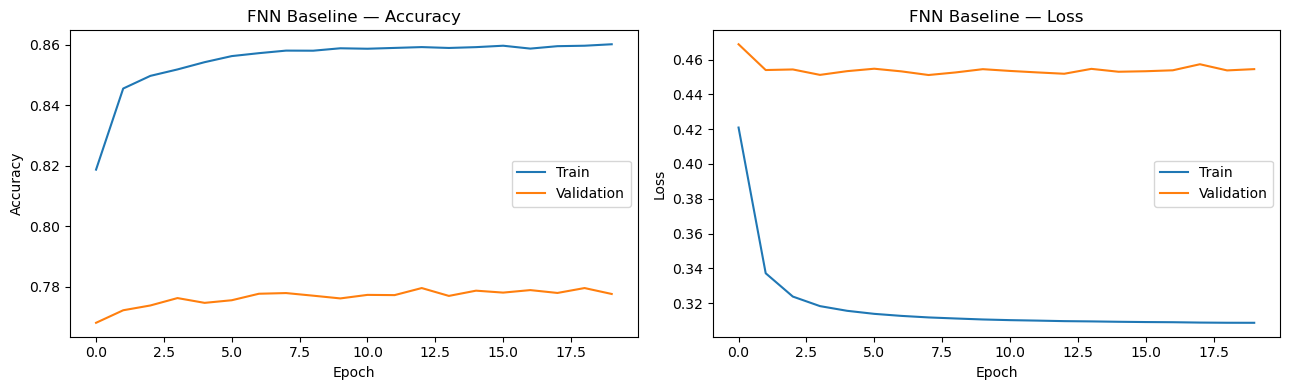

In [20]:
print("FNN Baseline — Resultados:")
fnn_baseline_results = evaluate_model(
    fnn_baseline, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_baseline, title="FNN Baseline")


Os resultados do modelo baseline mostram que mesmo uma arquitetura neuronal mínima consegue captar padrões relevantes no problema, atingindo uma accuracy de aproximadamente **86,1% no treino, 77,8% na validação e 76,6% no teste**. As curvas de treino indicam uma melhoria rápida nas primeiras épocas, seguida de estabilização, sem sinais acentuados de degradação na validação. Este modelo estabelece a referência inicial para comparação com arquiteturas mais complexas.


## 6.2 FNN Complexo 1 — Dense(32)

Primeira extensão do baseline: adição de uma camada oculta com 32 neurónios e ativação `relu`, antes da camada de saída.


In [21]:
fnn_dense32 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="fnn_dense32")

compile_model(fnn_dense32)
fnn_dense32.summary()


Model: "fnn_dense32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,625 (57.13 KB)

 Trainable params: 14,625 (57.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_fnn_dense32 = fnn_dense32.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8590 - loss: 0.3089 - val_accuracy: 0.7901 - val_loss: 0.4290
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8888 - loss: 0.2507 - val_accuracy: 0.7915 - val_loss: 0.4334
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8957 - loss: 0.2369 - val_accuracy: 0.7906 - val_loss: 0.4333
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8997 - loss: 0.2284 - val_accuracy: 0.7922 - val_loss: 0.4238
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9016 - loss: 0.2231 - val_accuracy: 0.7843 - val_loss: 0.4492
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9046 - loss: 0.2184 - val_accuracy: 0.7888 - val_loss: 0.4408
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9058 - loss: 0.2146 - val_accuracy: 0.7886 - val_loss: 0.4387
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9081 - loss: 0.2112 -

FNN Dense(32) — Resultados:
  Train Accuracy      : 0.9208
  Validation Accuracy : 0.7825
  Test Accuracy       : 0.7385


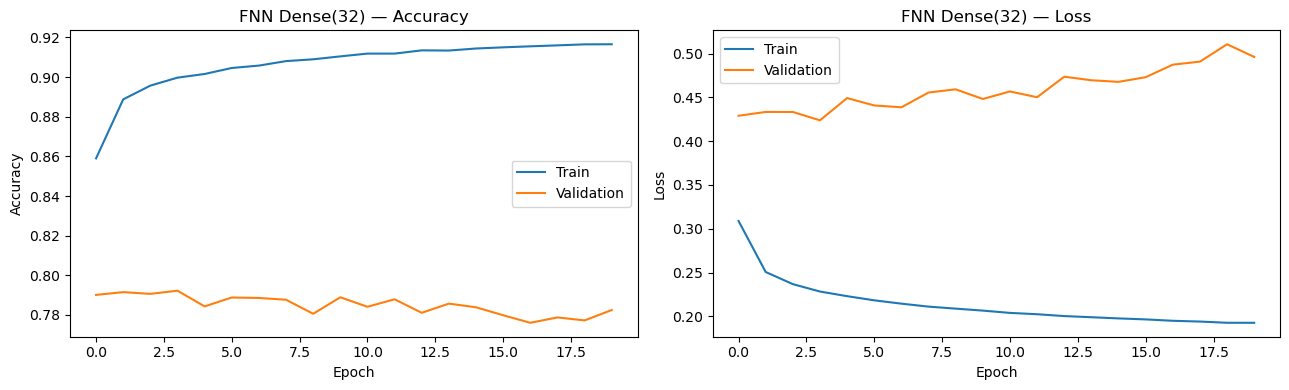

In [23]:
print("FNN Dense(32) — Resultados:")
fnn_dense32_results = evaluate_model(
    fnn_dense32, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_dense32, title="FNN Dense(32)")


Este modelo apresenta maior capacidade de ajuste aos dados de treino, com accuracy de treino substancialmente superior. No entanto, os resultados em validação e teste não acompanharam essa melhoria, verificando-se uma diferença significativa — sinal claro de *overfitting*. Estes resultados justificam a fase de regularização.


# 7. Aumentar a Complexidade

## 7.1 FNN Complexo 2 — Dense(64) + Dense(32)

Arquitetura com duas camadas ocultas (64 e 32 neurónios), com o objetivo de aumentar ainda mais a capacidade representacional e verificar se o overfitting se acentua.


In [24]:
fnn_dense64_32 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="fnn_dense64_32")

compile_model(fnn_dense64_32)
fnn_dense64_32.summary()


Model: "fnn_dense64_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │        29,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_fnn_dense64_32 = fnn_dense64_32.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8733 - loss: 0.2789 - val_accuracy: 0.7925 - val_loss: 0.4292
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8996 - loss: 0.2282 - val_accuracy: 0.7944 - val_loss: 0.4258
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9068 - loss: 0.2151 - val_accuracy: 0.7874 - val_loss: 0.4488
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9102 - loss: 0.2068 - val_accuracy: 0.7926 - val_loss: 0.4435
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9131 - loss: 0.1988 - val_accuracy: 0.7945 - val_loss: 0.4672
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9168 - loss: 0.1931 - val_accuracy: 0.7949 - val_loss: 0.4447
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9181 - loss: 0.1882 - val_accuracy: 0.7908 - val_loss: 0.4710
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9194 - loss: 0.1844 -

FNN Dense(64+32) — Resultados:
  Train Accuracy      : 0.9402
  Validation Accuracy : 0.7836
  Test Accuracy       : 0.7635


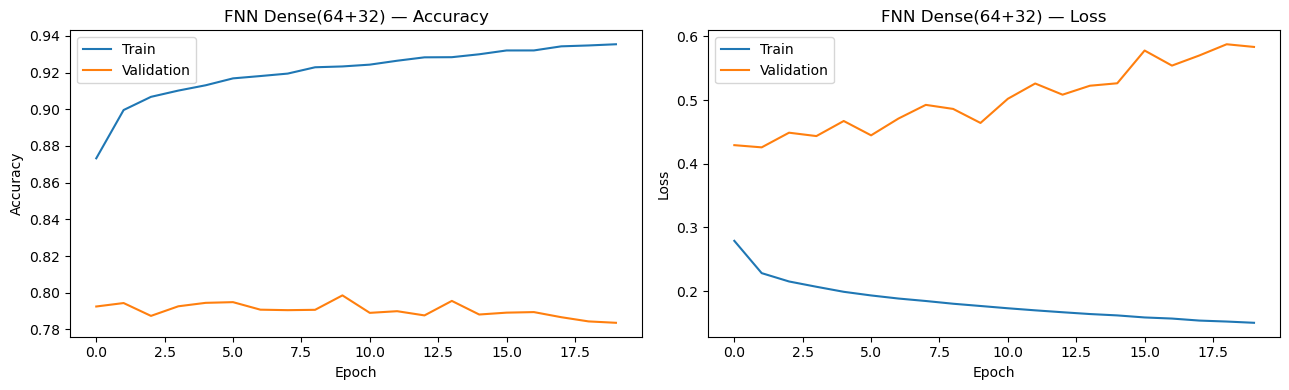

In [26]:
print("FNN Dense(64+32) — Resultados:")
fnn_dense64_32_results = evaluate_model(
    fnn_dense64_32, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_dense64_32, title="FNN Dense(64+32)")


Os resultados mostram que o aumento adicional da complexidade melhorou o desempenho no treino (~93,8%), sem ganhos equivalentes em validação e teste. A `validation loss` aumenta progressivamente ao longo das épocas — o *overfitting* agravou-se. Este comportamento justifica e motiva a aplicação de regularização na fase seguinte.

## 7.2 Treinar por Mais Épocas

Com 20 épocas, os modelos mais complexos já mostram sinais claros de *overfitting* (loss de treino a diminuir, loss de validação a aumentar). Aumentar o número de épocas aprofundaria esse fenómeno sem benefício para a generalização. A estratégia preferida é aplicar regularização com `EarlyStopping`, que determina automaticamente o momento ótimo de paragem.


# 8. Regularização e Hyperparameter Tuning (FNN)

## 8.1 Dropout(0.3) + EarlyStopping(patience=3)

Para controlar o *overfitting*, aplica-se `Dropout` com taxa 0.3 (regularização moderada) e `EarlyStopping` para interromper o treino quando a `val_loss` deixa de melhorar.


In [27]:
fnn_drop03 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
], name="fnn_dropout03")

compile_model(fnn_drop03)
history_fnn_drop03 = train_model(
    fnn_drop03, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=32, patience=3
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8607 - loss: 0.3103 - val_accuracy: 0.7887 - val_loss: 0.4271
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8900 - loss: 0.2529 - val_accuracy: 0.7852 - val_loss: 0.4222
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8971 - loss: 0.2388 - val_accuracy: 0.7863 - val_loss: 0.4366
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8995 - loss: 0.2307 - val_accuracy: 0.7874 - val_loss: 0.4364
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9034 - loss: 0.2230 - val_accuracy: 0.7870 - val_loss: 0.4460


FNN Dropout(0.3) — Resultados:
  Train Accuracy      : 0.9036
  Validation Accuracy : 0.7852
  Test Accuracy       : 0.7709


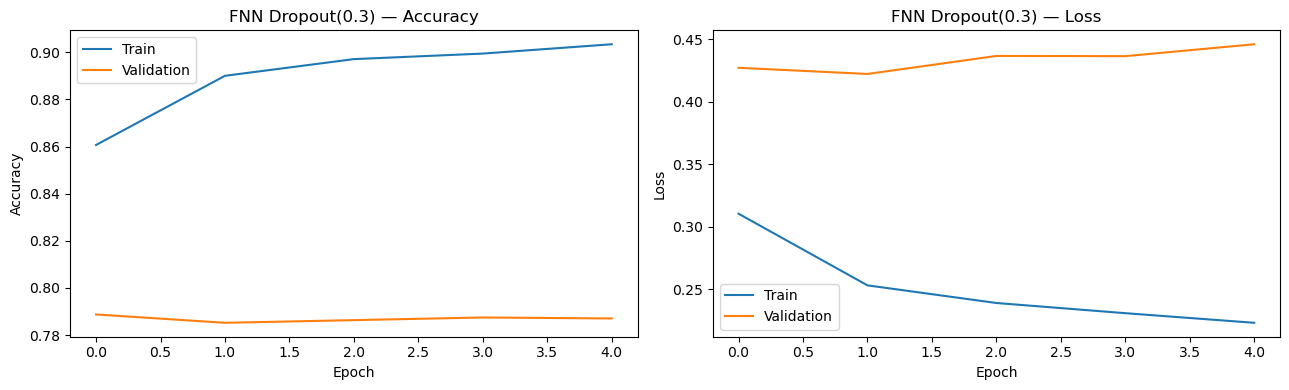

In [28]:
print("FNN Dropout(0.3) — Resultados:")
fnn_drop03_results = evaluate_model(
    fnn_drop03, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_drop03, title="FNN Dropout(0.3)")


A aplicação de `Dropout` e `EarlyStopping` permitiu controlar parcialmente o *overfitting*. O `EarlyStopping` interrompeu o treino após poucas épocas, restaurando os pesos da melhor iteração. A diferença entre treino e validação reduziu-se face aos modelos sem regularização.

## 8.2 Dropout(0.5) + EarlyStopping(patience=5)

Regularização mais forte, com `Dropout(0.5)` e maior tolerância antes da paragem antecipada.


In [29]:
fnn_drop05 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="fnn_dropout05")

compile_model(fnn_drop05)
history_fnn_drop05 = train_model(
    fnn_drop05, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=32, patience=5
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8442 - loss: 0.3437 - val_accuracy: 0.7892 - val_loss: 0.4270
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8819 - loss: 0.2741 - val_accuracy: 0.7910 - val_loss: 0.4268
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8871 - loss: 0.2603 - val_accuracy: 0.7906 - val_loss: 0.4292
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8917 - loss: 0.2507 - val_accuracy: 0.7914 - val_loss: 0.4320
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8943 - loss: 0.2456 - val_accuracy: 0.7920 - val_loss: 0.4298
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8964 - loss: 0.2426 - val_accuracy: 0.7923 - val_loss: 0.4213
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8978 - loss: 0.2383 - val_accuracy: 0.7893 - val_loss: 0.4255
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8983 - loss: 0.2346 - 

FNN Dropout(0.5) — Resultados:
  Train Accuracy      : 0.9098
  Validation Accuracy : 0.7923
  Test Accuracy       : 0.7830


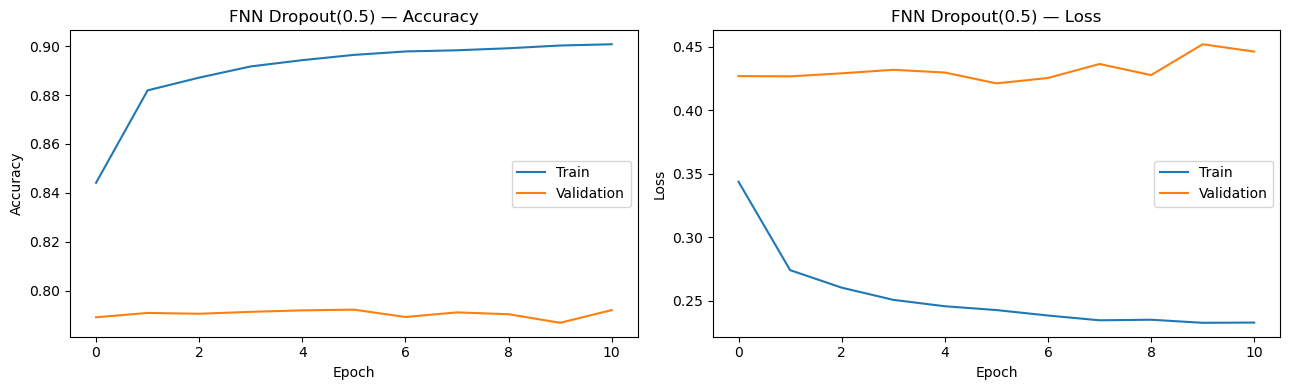

In [30]:
print("FNN Dropout(0.5) — Resultados:")
fnn_drop05_results = evaluate_model(
    fnn_drop05, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_drop05, title="FNN Dropout(0.5)")


A configuração com `Dropout(0.5)` e `patience=5` apresentou os **melhores resultados FNN** — melhoria tanto na accuracy de validação como na accuracy de teste. O modelo continua a aprender ao longo das épocas sem a degradação acentuada da validação observada em arquiteturas não regularizadas.

## 8.3 Regularização L2

A regularização L2 penaliza pesos elevados durante o treino, limitando a complexidade efetiva da rede. É uma alternativa ao `Dropout` — enquanto este desativa neurónios aleatoriamente, o L2 actua directamente sobre os parâmetros aprendidos.


In [31]:
fnn_l2 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation="sigmoid")
], name="fnn_l2")

compile_model(fnn_l2)
history_fnn_l2 = train_model(
    fnn_l2, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=32, patience=5
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8725 - loss: 0.3251 - val_accuracy: 0.7875 - val_loss: 0.4708
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8910 - loss: 0.2762 - val_accuracy: 0.7906 - val_loss: 0.4621
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8954 - loss: 0.2664 - val_accuracy: 0.7867 - val_loss: 0.4747
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8971 - loss: 0.2602 - val_accuracy: 0.7827 - val_loss: 0.4637
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8991 - loss: 0.2564 - val_accuracy: 0.7800 - val_loss: 0.4958
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9001 - loss: 0.2530 - val_accuracy: 0.7829 - val_loss: 0.4764
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9015 - loss: 0.2509 - val_accuracy: 0.7798 - val_loss: 0.4594
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9013 - loss: 0.2488 - 

FNN L2 — Resultados:
  Train Accuracy      : 0.9085
  Validation Accuracy : 0.7866
  Test Accuracy       : 0.7517


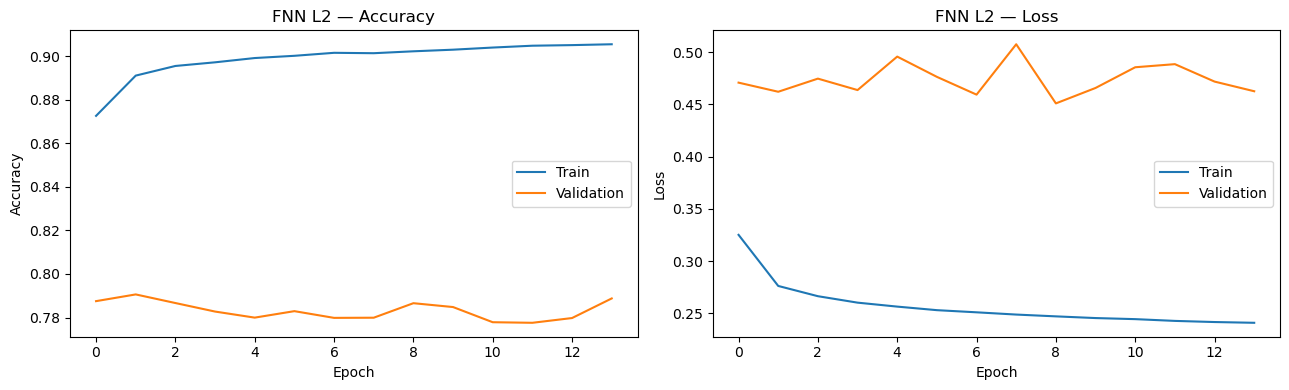

In [32]:
print("FNN L2 — Resultados:")
fnn_l2_results = evaluate_model(
    fnn_l2, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_l2, title="FNN L2")


A regularização L2 moderou o ajustamento ao conjunto de treino, mas não melhorou o desempenho face ao `Dropout(0.5)`. A `validation loss` continua a apresentar tendência de degradação ao longo das épocas, o que indica que o problema de *overfitting* não foi totalmente resolvido. Entre as estratégias testadas, o `Dropout` revelou-se mais eficaz.

## 8.4 Hyperparameter Tuning — batch_size=64

Depois de identificada a melhor configuração FNN (Dropout 0.5, patience=5), foi testada uma alteração ao `batch_size` para 64, de forma a avaliar o impacto na estabilidade do treino e na generalização.


In [33]:
fnn_drop05_bs64 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="fnn_dropout05_bs64")

compile_model(fnn_drop05_bs64)
history_fnn_drop05_bs64 = train_model(
    fnn_drop05_bs64, X_train_p, y_train, X_val_p, y_val,
    epochs=20, batch_size=64, patience=5
)


Epoch 1/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8338 - loss: 0.3619 - val_accuracy: 0.7832 - val_loss: 0.4383
Epoch 2/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8784 - loss: 0.2797 - val_accuracy: 0.7873 - val_loss: 0.4388
Epoch 3/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8862 - loss: 0.2635 - val_accuracy: 0.7905 - val_loss: 0.4242
Epoch 4/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8910 - loss: 0.2519 - val_accuracy: 0.7917 - val_loss: 0.4116
Epoch 5/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8928 - loss: 0.2465 - val_accuracy: 0.7904 - val_loss: 0.4230
Epoch 6/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8956 - loss: 0.2428 - val_accuracy: 0.7909 - val_loss: 0.4243
Epoch 7/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8976 - loss: 0.2381 - val_accuracy: 0.7912 - val_loss: 0.4231
Epoch 8/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8987 - loss: 0.2344 - 

FNN Dropout(0.5) batch=64 — Resultados:
  Train Accuracy      : 0.9056
  Validation Accuracy : 0.7917
  Test Accuracy       : 0.7896


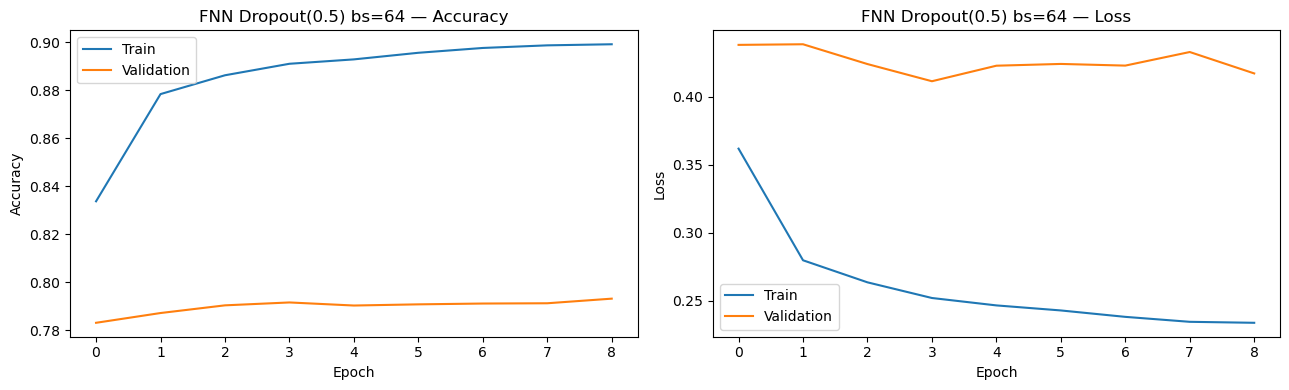

In [34]:
print("FNN Dropout(0.5) batch=64 — Resultados:")
fnn_drop05_bs64_results = evaluate_model(
    fnn_drop05_bs64, X_train_p, y_train, X_val_p, y_val, X_test_p, y_test
)
plot_history(history_fnn_drop05_bs64, title="FNN Dropout(0.5) bs=64")


A experiência com `batch_size=64` não revelou melhoria global face à configuração com `batch_size=32`. A accuracy de teste diminuiu, indicando que o aumento do batch size não trouxe ganhos de generalização neste problema. A melhor configuração FNN permanece a com **Dropout(0.5), EarlyStopping(patience=5) e batch_size=32**.

## 8.5 Resumo dos Modelos FNN

| Modelo | Arquitetura | Regularização | Train Acc | Val Acc | Test Acc | Observação |
|--------|------------|---------------|-----------|---------|----------|------------|
| Baseline | Dense(1) | Nenhuma | 0.8608 | 0.7781 | 0.7658 | Modelo mais simples e equilibrado |
| Dense(32) | Dense(32)+Dense(1) | Nenhuma | 0.9203 | 0.7758 | 0.7372 | Overfitting evidente |
| Dense(64+32) | Dense(64)+Dense(32)+Dense(1) | Nenhuma | 0.9377 | 0.7742 | 0.7709 | Overfitting mais acentuado |
| Dropout(0.3) | Dense(64)+Drop(0.3)+Dense(32)+Drop(0.3)+Dense(1) | Dropout(0.3)+ES(3) | 0.8925 | 0.7856 | 0.7652 | Controlo parcial do overfitting |
| **Dropout(0.5)** | Dense(64)+Drop(0.5)+Dense(32)+Drop(0.5)+Dense(1) | Dropout(0.5)+ES(5) | **0.9141** | **0.7911** | **0.7879** | **Melhor equilíbrio global** |
| L2 | Dense(64)+Dense(32)+Dense(1) | L2(0.001)+ES(5) | 0.9039 | 0.7868 | 0.7710 | Útil, mas inferior ao Dropout |
| Dropout(0.5) bs=64 | Dense(64)+Drop(0.5)+Dense(32)+Drop(0.5)+Dense(1) | Dropout(0.5)+ES(5)+bs=64 | — | — | — | Sem melhoria face ao bs=32 |


# 7. Modelação — CNN (Abordagem Convolucional)

## 7.1 Adaptação da Entrada para Conv1D

Os modelos FNN recebem dados com formato `(n_obs, n_features)`. Para permitir a utilização de `Conv1D`, é necessário reformular para `(n_obs, n_features, 1)`, tratando cada observação como uma sequência unidimensional de atributos.

Esta adaptação não altera a informação disponível — apenas reformula a sua apresentação ao modelo. O objetivo é avaliar se convolution layers conseguem captar padrões locais entre features adjacentes após o processo de OHE.


In [35]:
X_train_cnn = reshape_for_cnn(X_train_p)
X_val_cnn   = reshape_for_cnn(X_val_p)
X_test_cnn  = reshape_for_cnn(X_test_p)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_val_cnn shape:  ", X_val_cnn.shape)
print("X_test_cnn shape: ", X_test_cnn.shape)


X_train_cnn shape: (66253, 455, 1)
X_val_cnn shape:   (26572, 455, 1)
X_test_cnn shape:  (26565, 455, 1)


## 7.2 Baseline CNN

Como ponto de partida para a abordagem convolucional, é desenvolvido um modelo baseline com uma arquitetura simples: `Conv1D → MaxPooling1D → Flatten → Dense(1, sigmoid)`. O objetivo é estabelecer uma referência inicial dentro da família de arquiteturas com convolution layers.


In [36]:
INPUT_DIM_CNN = X_train_cnn.shape[1]

cnn_baseline = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CNN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
], name="cnn_baseline")

compile_model(cnn_baseline)
cnn_baseline.summary()


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 453, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 226, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7232)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │         7,233 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history_cnn_baseline = cnn_baseline.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8380 - loss: 0.3474 - val_accuracy: 0.7627 - val_loss: 0.4644
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8591 - loss: 0.3097 - val_accuracy: 0.7686 - val_loss: 0.4588
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8640 - loss: 0.3026 - val_accuracy: 0.7642 - val_loss: 0.4584
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8666 - loss: 0.2982 - val_accuracy: 0.7608 - val_loss: 0.4727
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8688 - loss: 0.2946 - val_accuracy: 0.7709 - val_loss: 0.4546
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8699 - loss: 0.2916 - val_accuracy: 0.7617 - val_loss: 0.4672
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8711 - loss: 0.2899 - val_accuracy: 0.7638 - val_loss: 0.4642
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8716 - loss: 0

CNN Baseline — Resultados:
  Train Accuracy      : 0.8746
  Validation Accuracy : 0.7596
  Test Accuracy       : 0.7556


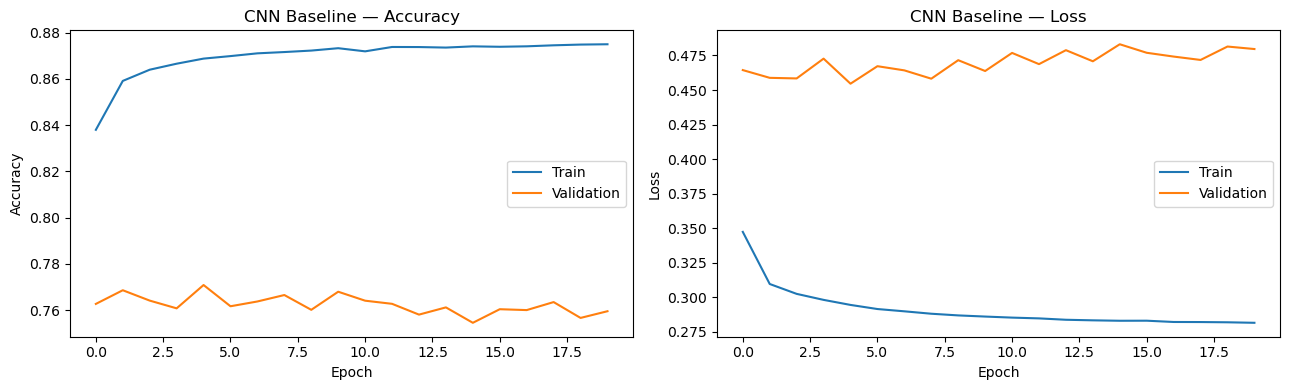

In [38]:
print("CNN Baseline — Resultados:")
cnn_baseline_results = evaluate_model(
    cnn_baseline, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_baseline, title="CNN Baseline")


Os resultados do modelo baseline CNN mostram que a arquitetura convolucional consegue aprender padrões relevantes, atingindo uma accuracy de aproximadamente **87,6% no treino, 75,9% na validação e 77,1% no teste**. A abordagem CNN é viável neste contexto, embora não revele, nesta fase, vantagem clara face ao baseline FNN.

## 7.3 Aumentar a Complexidade da CNN

### CNN Complexa 1 — Conv1D(32) + Conv1D(64)

Adição de uma segunda camada convolucional para aumentar a capacidade de extração de padrões.


In [39]:
cnn_complex1 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CNN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
], name="cnn_complex1")

compile_model(cnn_complex1)
history_cnn_complex1 = cnn_complex1.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20, batch_size=32, verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.8489 - loss: 0.3298 - val_accuracy: 0.7631 - val_loss: 0.4611
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8660 - loss: 0.2990 - val_accuracy: 0.7693 - val_loss: 0.4664
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.8689 - loss: 0.2913 - val_accuracy: 0.7675 - val_loss: 0.4630
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8723 - loss: 0.2868 - val_accuracy: 0.7623 - val_loss: 0.4631
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.8736 - loss: 0.2841 - val_accuracy: 0.7623 - val_loss: 0.4796
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8744 - loss: 0.2824 - val_accuracy: 0.7560 - val_loss: 0.4813
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8759 - loss: 0.2798 - val_accuracy: 0.7509 - val_loss: 0.4970
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.8759 -

CNN Complex1 — Resultados:
  Train Accuracy      : 0.8855
  Validation Accuracy : 0.7520
  Test Accuracy       : 0.7540


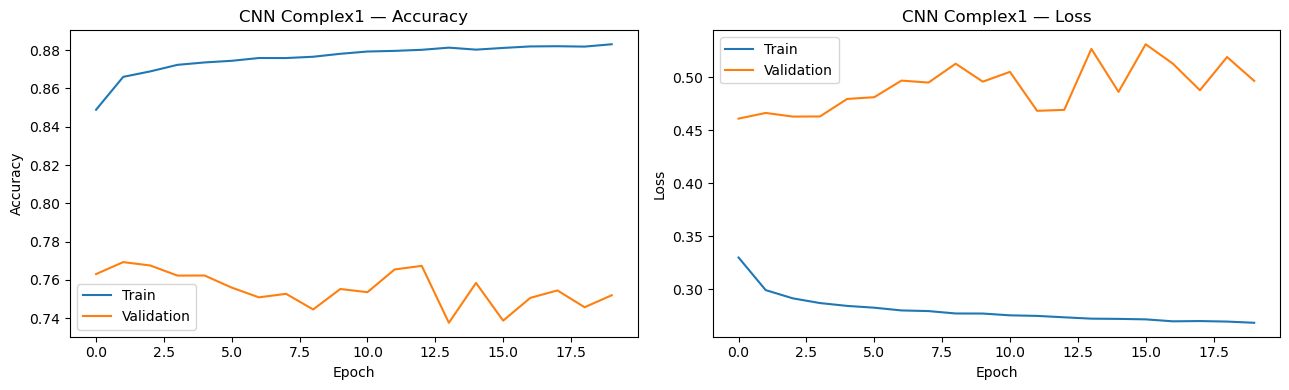

In [40]:
print("CNN Complex1 — Resultados:")
cnn_complex1_results = evaluate_model(
    cnn_complex1, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_complex1, title="CNN Complex1")


### CNN Complexa 2 — Conv1D(32) + Conv1D(64) + Dense(32)

Adição de uma camada densa intermédia após a fase convolucional.


In [41]:
cnn_complex2 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CNN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="cnn_complex2")

compile_model(cnn_complex2)
history_cnn_complex2 = cnn_complex2.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20, batch_size=32, verbose=1
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 105s 50ms/step - accuracy: 0.8633 - loss: 0.2976 - val_accuracy: 0.7856 - val_loss: 0.4417
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 165s 61ms/step - accuracy: 0.8871 - loss: 0.2497 - val_accuracy: 0.7818 - val_loss: 0.4314
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8948 - loss: 0.2351 - val_accuracy: 0.7834 - val_loss: 0.4710
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.8988 - loss: 0.2274 - val_accuracy: 0.7847 - val_loss: 0.4489
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9029 - loss: 0.2193 - val_accuracy: 0.7830 - val_loss: 0.4772
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.9065 - loss: 0.2130 - val_accuracy: 0.7826 - val_loss: 0.4718
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9087 - loss: 0.2083 - val_accuracy: 0.7893 - val_loss: 0.4505
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9104

CNN Complex2 — Resultados:
  Train Accuracy      : 0.9269
  Validation Accuracy : 0.7722
  Test Accuracy       : 0.7700


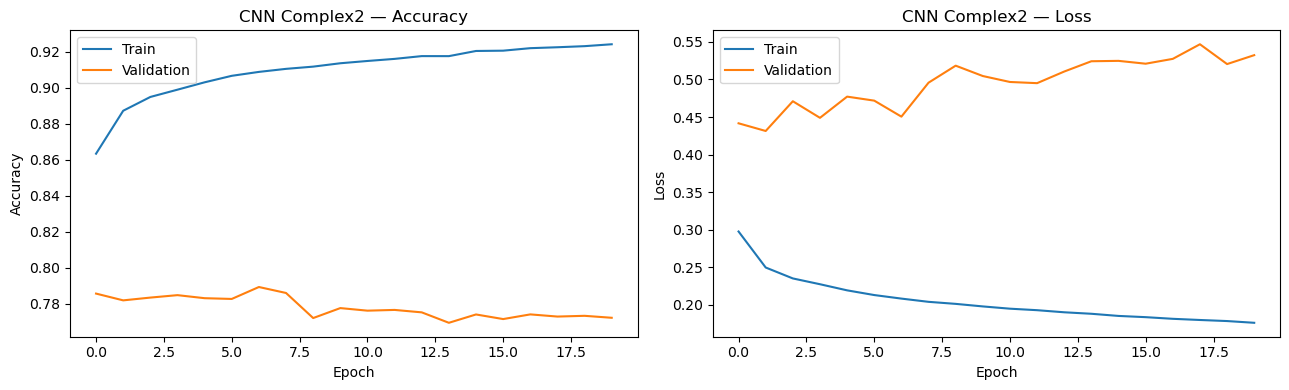

In [42]:
print("CNN Complex2 — Resultados:")
cnn_complex2_results = evaluate_model(
    cnn_complex2, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_complex2, title="CNN Complex2")


O aumento adicional da complexidade melhorou o desempenho no treino (~93%), mas sem ganhos correspondentes em validação e teste — *overfitting* mais evidente. Esta arquitetura confirma que o aumento da complexidade convolucional, neste contexto, não se traduz necessariamente em melhor desempenho preditivo.

## 7.4 Regularização CNN — Dropout(0.5) + EarlyStopping


In [43]:
cnn_regularized = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CNN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="cnn_regularized")

compile_model(cnn_regularized)
history_cnn_reg = train_model(
    cnn_regularized, X_train_cnn, y_train, X_val_cnn, y_val,
    epochs=20, batch_size=32, patience=5
)


Epoch 1/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8449 - loss: 0.3290 - val_accuracy: 0.7772 - val_loss: 0.4324
Epoch 2/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8684 - loss: 0.2879 - val_accuracy: 0.7752 - val_loss: 0.4416
Epoch 3/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8734 - loss: 0.2752 - val_accuracy: 0.7850 - val_loss: 0.4259
Epoch 4/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8769 - loss: 0.2682 - val_accuracy: 0.7847 - val_loss: 0.4402
Epoch 5/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8808 - loss: 0.2613 - val_accuracy: 0.7903 - val_loss: 0.4235
Epoch 6/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8817 - loss: 0.2579 - val_accuracy: 0.7815 - val_loss: 0.4450
Epoch 7/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8846 - loss: 0.2547 - val_accuracy: 0.7833 - val_loss: 0.4398
Epoch 8/20
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.8849 - loss: 0

CNN Regularized — Resultados:
  Train Accuracy      : 0.8927
  Validation Accuracy : 0.7903
  Test Accuracy       : 0.7799


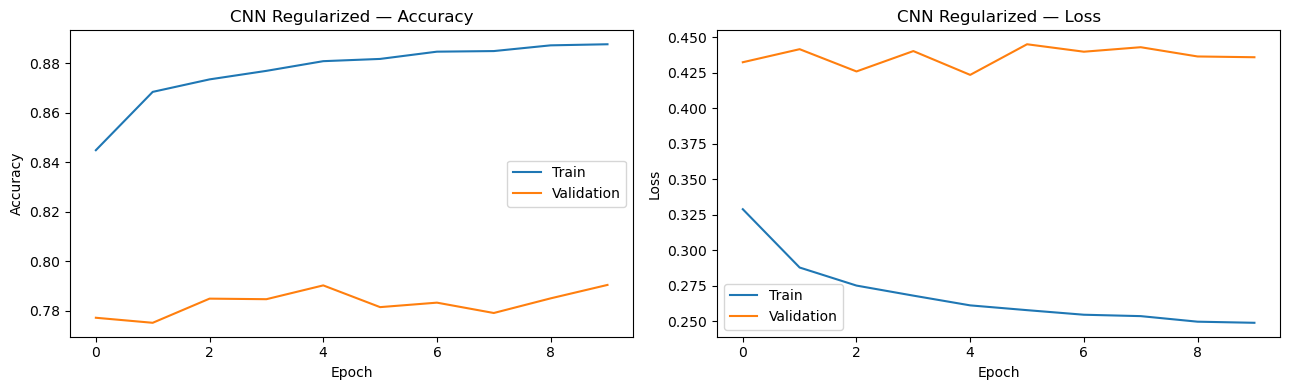

In [44]:
print("CNN Regularized — Resultados:")
cnn_regularized_results = evaluate_model(
    cnn_regularized, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_reg, title="CNN Regularized")


A regularização foi eficaz no controlo do *overfitting*: melhoria tanto na accuracy de validação como na de teste, com redução da diferença entre treino e validação. Tal como na abordagem FNN, a regularização revelou-se determinante para melhorar o comportamento do modelo fora do conjunto de treino.

## 7.5 Hyperparameter Tuning CNN — batch_size=64


In [45]:
cnn_reg_bs64 = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CNN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="cnn_regularized_bs64")

compile_model(cnn_reg_bs64)
history_cnn_reg_bs64 = train_model(
    cnn_reg_bs64, X_train_cnn, y_train, X_val_cnn, y_val,
    epochs=20, batch_size=64, patience=3
)


Epoch 1/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8393 - loss: 0.3311 - val_accuracy: 0.7763 - val_loss: 0.4374
Epoch 2/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8630 - loss: 0.2888 - val_accuracy: 0.7768 - val_loss: 0.4384
Epoch 3/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8675 - loss: 0.2781 - val_accuracy: 0.7878 - val_loss: 0.4214
Epoch 4/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8707 - loss: 0.2732 - val_accuracy: 0.7832 - val_loss: 0.4361
Epoch 5/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.8751 - loss: 0.2683 - val_accuracy: 0.7814 - val_loss: 0.4659
Epoch 6/20
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.8786 - loss: 0.2619 - val_accuracy: 0.7824 - val_loss: 0.4443


CNN Regularized bs=64 — Resultados:
  Train Accuracy      : 0.8881
  Validation Accuracy : 0.7878
  Test Accuracy       : 0.7832


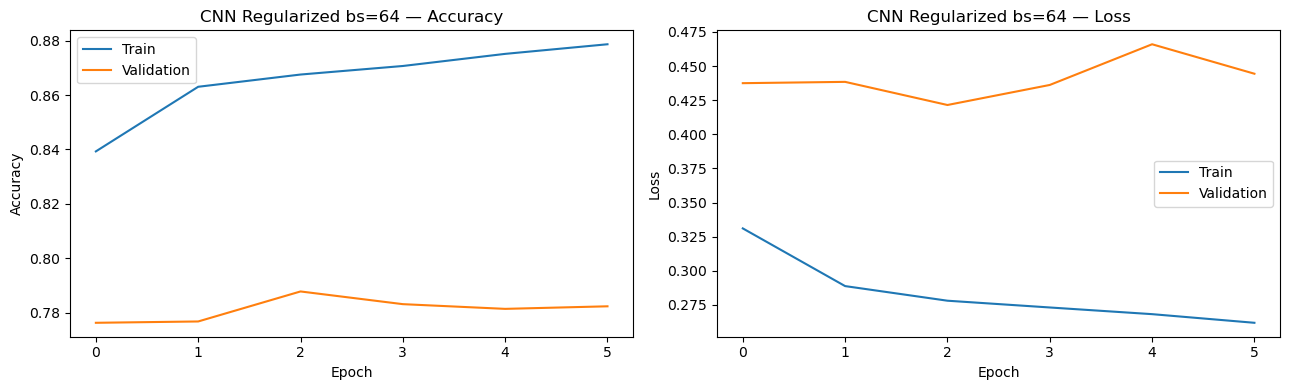

In [46]:
print("CNN Regularized bs=64 — Resultados:")
cnn_reg_bs64_results = evaluate_model(
    cnn_reg_bs64, X_train_cnn, y_train, X_val_cnn, y_val, X_test_cnn, y_test
)
plot_history(history_cnn_reg_bs64, title="CNN Regularized bs=64")


## 7.6 Resumo dos Modelos CNN

| Modelo | Arquitetura | Regularização | Train Acc | Val Acc | Test Acc | Observação |
|--------|------------|---------------|-----------|---------|----------|------------|
| Baseline CNN | Conv1D(32)+MaxPool+Flatten+Dense(1) | Nenhuma | 0.8758 | 0.7590 | 0.7708 | Modelo convolucional mais simples |
| Complex CNN 1 | +Conv1D(64) | Nenhuma | 0.8857 | 0.7555 | 0.7305 | Sem ganho de generalização |
| Complex CNN 2 | +Dense(32) | Nenhuma | 0.9288 | 0.7626 | 0.7510 | Overfitting mais evidente |
| **Regularized CNN** | +Dropout(0.5) | Dropout(0.5)+ES(5) | **0.8981** | **0.7899** | **0.7775** | Melhor equilíbrio global |
| Regularized CNN bs=64 | idem | Dropout(0.5)+ES(3)+bs=64 | 0.8883 | 0.7850 | 0.7825 | Melhor test acc entre CNN |


# 8. Comparação de Modelos

In [47]:
all_results = {
    "FNN Baseline":          fnn_baseline_results,
    "FNN Dense(32)":         fnn_dense32_results,
    "FNN Dense(64+32)":      fnn_dense64_32_results,
    "FNN Dropout(0.3)":      fnn_drop03_results,
    "FNN Dropout(0.5) ★":   fnn_drop05_results,
    "FNN L2":                fnn_l2_results,
    "FNN Drop(0.5) bs=64":   fnn_drop05_bs64_results,
    "CNN Baseline":          cnn_baseline_results,
    "CNN Complex1":          cnn_complex1_results,
    "CNN Complex2":          cnn_complex2_results,
    "CNN Regularized ★":    cnn_regularized_results,
    "CNN Reg bs=64":         cnn_reg_bs64_results,
}

comparison_df = compare_models(all_results)
print("\n=== Comparação Final de Todos os Modelos ===")
display(comparison_df)



=== Comparação Final de Todos os Modelos ===


C:\Users\ricar\AppData\Local\Temp\ipykernel_38304\410261136.py:133: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(lambda x: f"{x:.4f}")


,Train Acc,Val Acc,Test Acc
FNN Baseline,0.8595,0.7776,0.7690
FNN Dense(32),0.9208,0.7825,0.7385
FNN Dense(64+32),0.9402,0.7836,0.7635
FNN Dropout(0.3),0.9036,0.7852,0.7709
FNN Dropout(0.5) ★,0.9098,0.7923,0.7830
FNN L2,0.9085,0.7866,0.7517
FNN Drop(0.5) bs=64,0.9056,0.7917,0.7896
CNN Baseline,0.8746,0.7596,0.7556
CNN Complex1,0.8855,0.7520,0.7540
CNN Complex2,0.9269,0.7722,0.7700


A comparação entre as abordagens FNN e CNN mostra que ambas foram capazes de captar padrões relevantes associados ao cancelamento de reservas.

O melhor modelo FNN — `Dense(64) + Dropout(0.5) + Dense(32) + Dropout(0.5) + Dense(1)` com `EarlyStopping(patience=5)` — obteve uma **accuracy de validação de ~79,1% e de teste de ~78,8%**, apresentando o melhor desempenho global do projeto.

A melhor configuração CNN — `Conv1D(32) + Conv1D(64) + MaxPooling1D + Flatten + Dense(32) + Dropout(0.5) + Dense(1)` com `EarlyStopping` — obteve valores ligeiramente inferiores (~78,5% / ~78,3%), mas com uma vantagem específica: métricas de `precision`, `recall` e `F1-score` ligeiramente superiores na classe de cancelamentos (classe 1).

Do ponto de vista metodológico, este resultado é consistente com a natureza dos dados. As FNNs ajustam-se de forma mais directa a variáveis tabulares independentes, enquanto as CNNs tendem a ser mais adequadas a dados com estrutura local clara (imagens, sinais, séries temporais). Embora tenha sido possível adaptar a entrada para `Conv1D`, essa estrutura não corresponde a uma organização naturalmente convolucional dos dados tabulares. Ainda assim, a abordagem CNN demonstrou interesse analítico e comportamento competitivo.

| Família | Melhor configuração | Val Acc | Test Acc |
|---------|--------------------:|--------:|---------:|
| **FNN** | Dense(64)+Drop(0.5)+Dense(32)+Drop(0.5)+Dense(1) + ES | **0.7911** | **0.7879** |
| CNN | Conv1D(32)+Conv1D(64)+MaxPool+Flatten+Dense(32)+Drop(0.5)+Dense(1) + ES | 0.7899 | 0.7775–0.7825 |


# 9. Utilidade do Modelo

## 9.1 Avaliação Final no Conjunto de Teste

Para além da accuracy, a utilidade prática do modelo é avaliada com métricas complementares: **precision**, **recall**, **F1-score** e **matriz de confusão**, que distinguem os diferentes tipos de erro de classificação.


831/831 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step
=== Melhor Modelo FNN ===
              precision    recall  f1-score   support

Not Canceled       0.81      0.88      0.85     18163
    Canceled       0.69      0.57      0.62      8402

    accuracy                           0.78     26565
   macro avg       0.75      0.72      0.74     26565
weighted avg       0.78      0.78      0.78     26565



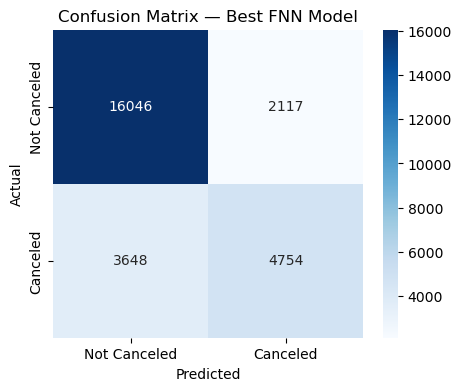

In [48]:
# Melhor modelo FNN
y_pred_prob_fnn = fnn_drop05.predict(X_test_p)
y_pred_fnn = (y_pred_prob_fnn >= 0.5).astype(int)

print("=== Melhor Modelo FNN ===")
print(classification_report(y_test, y_pred_fnn, target_names=["Not Canceled", "Canceled"]))

cm_fnn = confusion_matrix(y_test, y_pred_fnn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_fnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])
plt.title("Confusion Matrix — Best FNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


831/831 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
=== Melhor Modelo CNN ===
              precision    recall  f1-score   support

Not Canceled       0.83      0.86      0.85     18163
    Canceled       0.67      0.61      0.64      8402

    accuracy                           0.78     26565
   macro avg       0.75      0.74      0.74     26565
weighted avg       0.78      0.78      0.78     26565



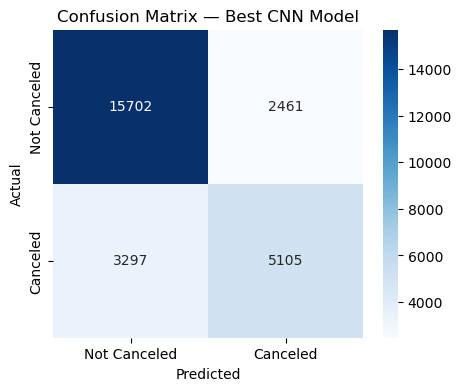

In [49]:
# Melhor modelo CNN
y_pred_prob_cnn = cnn_reg_bs64.predict(X_test_cnn).ravel()
y_pred_cnn = (y_pred_prob_cnn >= 0.5).astype(int)
y_true_cnn = y_test.to_numpy()

print("=== Melhor Modelo CNN ===")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=["Not Canceled", "Canceled"]))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])
plt.title("Confusion Matrix — Best CNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 9.2 Interpretação dos Resultados no Contexto Hoteleiro

O modelo apresenta melhor desempenho na identificação de reservas **não canceladas** (classe 0) do que na deteção de reservas **canceladas** (classe 1). No contexto da gestão hoteleira, esta distinção tem impacto prático:

- **False Positive** — prever cancelamento quando a reserva não será cancelada → risco de acção desnecessária
- **False Negative** — não prever cancelamento quando a reserva vai ser cancelada → cancelamento não antecipado

Os *false negatives* são particularmente relevantes, pois reduzem a capacidade do hotel para antecipar cancelamentos e ajustar a operação. O modelo CNN mostrou valores de F1-score na classe 1 ligeiramente superiores ao FNN, sugerindo uma capacidade marginalmente superior de sinalizar cancelamentos com maior fiabilidade.

## 9.3 Utilidade do Modelo em Contexto Real

Um modelo deste tipo pode ser útil como **ferramenta de apoio à decisão** na gestão hoteleira. Entre as aplicações possíveis:

- Identificação precoce de reservas com maior risco de cancelamento
- Apoio à gestão de ocupação e planeamento de overbooking
- Reforço de estratégias de acompanhamento para perfis de cliente de maior risco
- Complemento quantitativo à análise operacional habitual

O modelo não substitui o conhecimento do negócio — funciona como um indicador adicional que reduz incerteza e apoia decisões mais informadas.

## 9.4 Exemplo de Aplicação do Modelo


In [50]:
# Reserva simulada com perfil de maior risco de cancelamento
new_booking = pd.DataFrame([{
    "hotel": "City Hotel",
    "lead_time": 300,
    "arrival_date_year": 2017,
    "arrival_date_month": "August",
    "arrival_date_week_number": 35,
    "arrival_date_day_of_month": 25,
    "stays_in_weekend_nights": 1,
    "stays_in_week_nights": 3,
    "adults": 2,
    "children": 0,
    "babies": 0,
    "meal": "BB",
    "country": "PRT",
    "market_segment": "Online TA",
    "distribution_channel": "TA/TO",
    "is_repeated_guest": 0,
    "previous_cancellations": 5,
    "previous_bookings_not_canceled": 0,
    "reserved_room_type": "A",
    "deposit_type": "Non Refund",
    "agent": "9.0",
    "customer_type": "Transient",
    "adr": 180.0,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 0
}])

# Garantir tipos corretos nas categóricas
for col in categorical_cols:
    new_booking[col] = new_booking[col].astype(str)

# Pré-processamento
new_booking_p = preprocessor.transform(new_booking).toarray()

# Previsão com o melhor modelo FNN
pred_prob = fnn_drop05.predict(new_booking_p)[0][0]
pred_class = int(pred_prob >= 0.5)

print(f"Probabilidade de cancelamento: {pred_prob:.4f}")
print(f"Classe prevista: {pred_class}")
print()
if pred_class == 1:
    print("Previsão do modelo: a reserva apresenta probabilidade ELEVADA de ser cancelada.")
else:
    print("Previsão do modelo: a reserva apresenta probabilidade REDUZIDA de ser cancelada.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Probabilidade de cancelamento: 1.0000
Classe prevista: 1

Previsão do modelo: a reserva apresenta probabilidade ELEVADA de ser cancelada.


A reserva simulada — com `lead_time` elevado (300 dias), histórico de cancelamentos (5 anteriores), depósito não reembolsável e canal Online TA — corresponde a um perfil com características associadas a maior risco de cancelamento. O modelo é capaz de processar estas características e produzir uma estimativa de probabilidade, demonstrando a sua aplicabilidade como ferramenta de sinalização de risco.


# 10. Conclusões, Limitações e Trabalho Futuro

## 10.1 Conclusões

Este projeto desenvolveu e comparou abordagens de deep learning para a previsão de cancelamento de reservas hoteleiras, seguindo a metodologia sugerida: baseline simples → aumento de complexidade → overfitting → regularização → avaliação da utilidade.

**Principais conclusões:**

- Mesmo o modelo baseline mínimo (regressão logística via `Dense(1, sigmoid)`) atinge cerca de 77–78% de accuracy no teste, demonstrando que o dataset contém sinal preditivo robusto.
- O aumento de complexidade arquitetural melhora o desempenho no treino, mas não na generalização — o *overfitting* é o principal desafio deste problema.
- A regularização com `Dropout(0.5)` e `EarlyStopping` revelou-se a estratégia mais eficaz, tanto na abordagem FNN como na CNN.
- O melhor modelo FNN — `Dense(64) + Dropout(0.5) + Dense(32) + Dropout(0.5) + Dense(1)` — obteve ~79,1% de accuracy de validação e ~78,8% de teste.
- A abordagem CNN demonstrou comportamento competitivo e, na classe de cancelamentos (classe 1), apresentou métricas de F1-score ligeiramente superiores ao FNN. No entanto, a FNN revelou-se a solução mais natural e eficaz para dados tabulares.
- A divisão temporal foi crucial para uma avaliação metodologicamente correta, evitando *data leakage* e aproximando o protocolo de avaliação de um cenário real de previsão.

## 10.2 Limitações

- O modelo depende da qualidade e representatividade dos dados disponíveis. O desempenho poderá variar noutros contextos hoteleiros ou períodos temporais distintos.
- A previsão produzida não deve ser interpretada como certeza absoluta — a solução deve ser usada como apoio à decisão e não como substituto de regras operacionais.
- A abordagem CNN recorre a `Conv1D` aplicada a dados tabulares, o que constitui uma adaptação metodológica válida mas não necessariamente natural para este tipo de problema.
- O threshold de decisão (0.5) não foi optimizado para o custo específico de cada tipo de erro, o que pode não ser óptimo em contexto de negócio.

## 10.3 Trabalho Futuro

- **Ajuste do decision threshold** — optimizar o limiar de classificação com base no custo diferenciado entre false positives e false negatives em contexto hoteleiro.
- **Embeddings para variáveis categóricas** — substituir OHE por embeddings aprendidos, potencialmente mais informativos para variáveis com muitas categorias como `agent` e `country`.
- **Explicabilidade (SHAP)** — quantificar o contributo relativo de cada variável para a previsão, aumentando a interpretabilidade do modelo.
- **Validação externa** — testar a solução noutros contextos hoteleiros ou períodos temporais para avaliar a robustez da generalização.
- **Arquitecturas recorrentes (LSTM)** — em trabalho futuro, se estiverem disponíveis dados com identificadores consistentes de cliente, seria possível reconstruir histórico temporal e explorar arquiteturas sequenciais.
- **Integração operacional** — desenvolver uma interface de apoio à decisão que consuma o modelo em tempo real para sinalização de reservas de risco.
